# IY025: Why does the SVM succeed on the t_ac variation dataset?

The IY025 SVM pairwise experiment shows 81% accuracy on the IY014 t_ac variation dataset — surprisingly high given that only autocorrelation time varies while μ (1000 molecules) and CV (0.5) are both fixed.

This notebook investigates three hypotheses for how the SVM might be solving the same/different task:

1. **Where do the four datasets sit in (μ, CV) space?**  
   CV vs μ scatter for each variation dataset.

2. **What does the mRNA count distribution look like at different t_ac values?**  
   Even with identical μ and CV, the *shape* of the distribution (unimodal vs bimodal) changes with t_ac.

3. **Could the SVM be exploiting the fraction of timepoints above the mean?**  
   In bursty (high t_ac) trajectories, the gene spends long stretches near 0 and briefly at high expression. The fraction of timepoints where mRNA > 1000 (the fixed μ) should decrease with t_ac — providing a shortcut feature.

In [2]:
import sys
sys.path.insert(0, '../../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from scipy import stats

# ── Plotting conventions ──────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family':     'sans-serif',
    'axes.labelsize':  12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'axes.titlesize':  14,
})
PALETTE = sns.color_palette('colorblind')

RNG = np.random.default_rng(42)

In [3]:
# ── Paths ─────────────────────────────────────────────────────────────────────
IY011_ROOT = Path('../EXP-25-IY011')
IY014_ROOT = Path('../EXP-26-IY014')

DATASETS = [
    dict(
        name='baseline',
        data_dir=IY014_ROOT / 'data',
        csv='IY014_simulation_parameters_sobol.csv',
        color=PALETTE[0],
    ),
    dict(
        name='mu',
        data_dir=IY011_ROOT / 'data_mu_variation',
        csv='IY011_simulation_mu_parameters_sobol.csv',
        color=PALETTE[1],
    ),
    dict(
        name='cv',
        data_dir=IY014_ROOT / 'data_cv_variation',
        csv='IY014_simulation_cv_parameters_sobol.csv',
        color=PALETTE[2],
    ),
    dict(
        name='t_ac',
        data_dir=IY014_ROOT / 'data_t_ac_variation',
        csv='IY014_simulation_t_ac_parameters_sobol.csv',
        color=PALETTE[3],
    ),
]

# Fixed mu for the t_ac dataset
MU_FIXED = 1000.0
CV_FIXED = 0.5

## 1. CV vs μ scatter for all four variation datasets

Each point represents one parameter set; coordinates are the **observed** (simulated) mean and CV. This immediately shows what is and is not varied in each dataset.

In [4]:
def load_params_csv(ds):
    """Load and quality-filter the parameter CSV for a dataset."""
    df = pd.read_csv(ds['data_dir'] / ds['csv'])
    ok = (
        df['success'].astype(bool)
        & df['error_message'].isna()
        & (df['mean_rel_error_pct'] < 20)
        & (df['cv_rel_error_pct'] < 20)
        & (df['t_ac_rel_error_pct'] < 20)
    )
    return df[ok].reset_index(drop=True)

param_dfs = {ds['name']: load_params_csv(ds) for ds in DATASETS}
for name, df in param_dfs.items():
    print(f'{name:12s}: {len(df):4d} parameter sets')

baseline    :  977 parameter sets
mu          : 1024 parameter sets
cv          : 1024 parameter sets
t_ac        : 1012 parameter sets


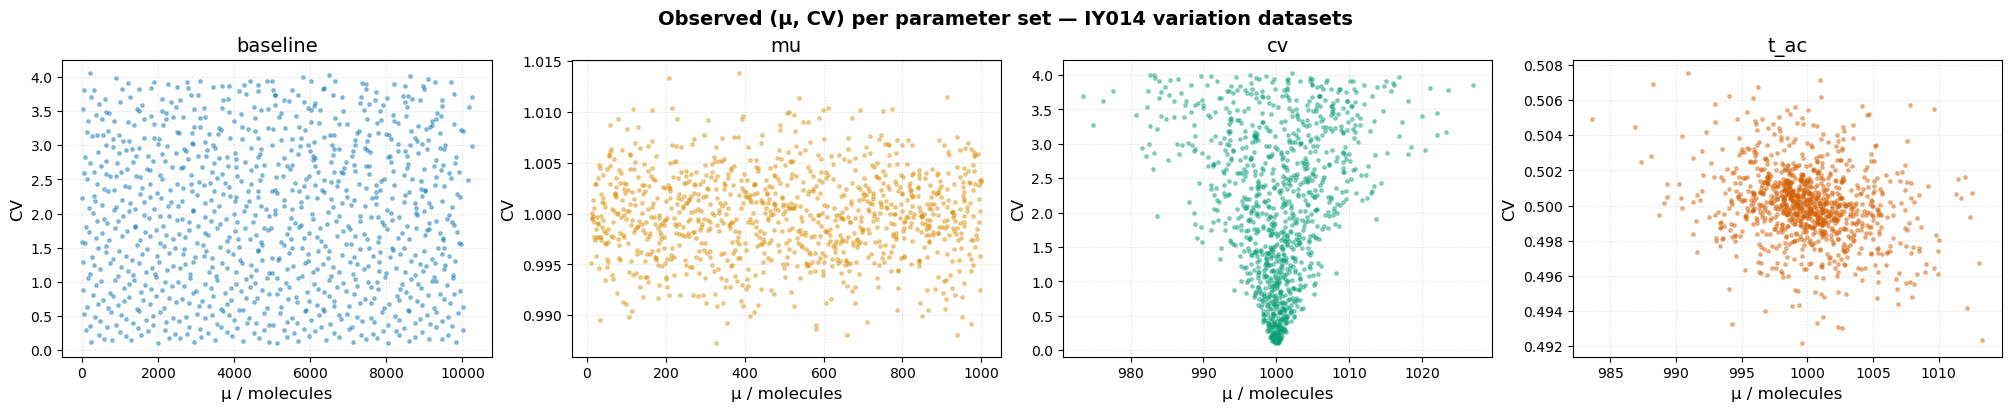

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4), constrained_layout=True)

for ax, ds in zip(axes, DATASETS):
    df = param_dfs[ds['name']]
    ax.scatter(
        df['mu_observed'], df['cv_observed'],
        color=ds['color'], alpha=0.4, s=6, rasterized=True,
    )
    ax.set_xlabel('μ / molecules', fontsize=12)
    ax.set_ylabel('CV', fontsize=12)
    ax.set_title(ds['name'], fontsize=14)
    ax.xaxis.set_major_formatter(mticker.ScalarFormatter(useMathText=True))
    # ax.ticklabel_format(style='sci', axis='x', scilimits=(0, 3))
    ax.grid(axis='both', linestyle=':', alpha=0.4)

fig.suptitle(
    'Observed (μ, CV) per parameter set — IY014 variation datasets',
    fontsize=14, weight='bold',
)
plt.savefig('figures/IY025_cv_vs_mu_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. mRNA count distribution at different t_ac values

All t_ac parameter sets share the same target μ = 1000 and CV = 0.5. Nevertheless, the **shape** of the count distribution can differ: fast switching (low t_ac) produces a broad unimodal distribution, while slow switching (high t_ac) produces a bimodal distribution with a peak near zero (gene OFF) and a peak at high expression (gene ON). These shape differences carry information about t_ac that is invisible to summary statistics of μ and CV alone.

In [6]:
tac_dir = DATASETS[3]['data_dir']
df_tac = param_dfs['t_ac'].copy()
df_tac['t_ac_target'] = df_tac['t_ac_target'].round(2)

# Select 4 representative t_ac values spread across the range
t_ac_targets = [2.5, 5.0, 30.0, 60.0, 120.0]  # approximate targets
selected_rows = [
    df_tac.iloc[(df_tac['t_ac_target'] - t).abs().argsort()[:1]]
    for t in t_ac_targets
]

for row in selected_rows:
    row = row.iloc[0]
    print(f"t_ac_target={row['t_ac_target']:.1f}  →  "
          f"observed t_ac={row['t_ac_observed']:.1f}  "
          f"μ={row['mu_observed']:.0f}  CV={row['cv_observed']:.2f}  "
          f"file={row['trajectory_filename']}")

t_ac_target=2.5  →  observed t_ac=2.5  μ=1000  CV=0.50  file=mRNA_trajectories_1000.000_0.500_2.490.csv
t_ac_target=5.0  →  observed t_ac=5.0  μ=999  CV=0.50  file=mRNA_trajectories_1000.000_0.500_4.966.csv
t_ac_target=30.0  →  observed t_ac=29.4  μ=995  CV=0.50  file=mRNA_trajectories_1000.000_0.500_29.987.csv
t_ac_target=60.0  →  observed t_ac=57.2  μ=999  CV=0.50  file=mRNA_trajectories_1000.000_0.500_59.956.csv
t_ac_target=120.0  →  observed t_ac=111.6  μ=1001  CV=0.49  file=mRNA_trajectories_1000.000_0.500_119.983.csv


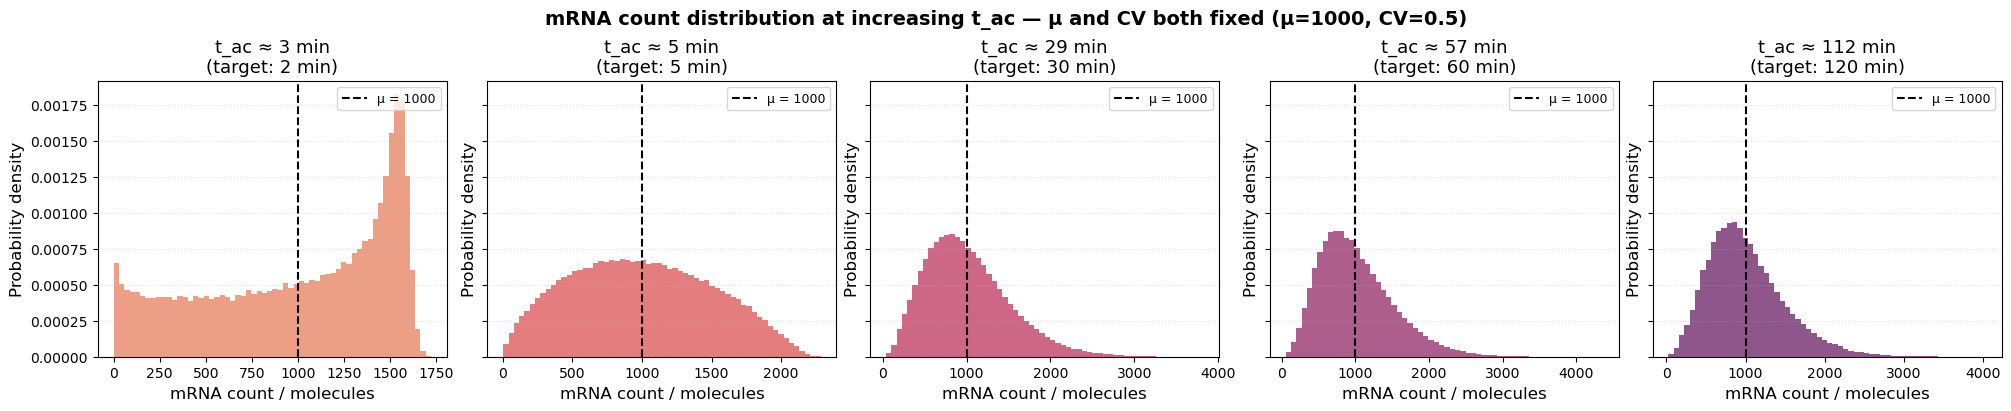

In [7]:
n_traj_per_hist = 100  # trajectories to pool per panel
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True, constrained_layout=True)
cmap_colors = sns.color_palette('flare', n_colors=5)

for ax, row_df, col in zip(axes, selected_rows, cmap_colors):
    row = row_df.iloc[0]
    npz_path = tac_dir / Path(row['trajectory_filename']).with_suffix('.npz').name
    data = np.load(npz_path, allow_pickle=True)
    trajs = data['trajectories'][:n_traj_per_hist]  # (n_traj, T)
    values = trajs.flatten()

    ax.hist(values, bins=60, density=True, color=col, alpha=0.8, edgecolor='none')
    ax.axvline(MU_FIXED, color='k', linestyle='--', linewidth=1.5, label=f'μ = {MU_FIXED:.0f}')
    ax.set_xlabel('mRNA count / molecules', fontsize=12)
    ax.set_ylabel('Probability density', fontsize=12)
    ax.set_title(
        f't_ac ≈ {row["t_ac_observed"]:.0f} min\n'
        f'(target: {row["t_ac_target"]:.0f} min)',
        fontsize=13
    )
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(axis='y', linestyle=':', alpha=0.4)

fig.suptitle(
    'mRNA count distribution at increasing t_ac — μ and CV both fixed (μ=1000, CV=0.5)',
    fontsize=14, weight='bold',
)
plt.savefig('figures/IY025_tac_count_histograms.png', dpi=150, bbox_inches='tight')
plt.show()

### 2b. Does this shape shift hold at other (μ, CV²) anchors?

The figure above is specific to μ=1000, CV=0.5 (CV²=0.25) — the one point baked into the IY014 t_ac variation dataset. To check whether the same t_ac-dependent shape shift appears elsewhere, we run fresh, lightweight simulations (200 trajectories per point, same approach as Section 4 below) at the same 5 t_ac targets, across μ ∈ {300, 1000, 2000} and CV ∈ {0.5, 1.0, 1.5}, and recreate the histogram figure at each anchor — one figure per CV value, with μ as rows and t_ac as columns.

In [8]:
from simulation.julia_simulate_telegraph_model import simulate_telegraph_model
from simulation.mean_cv_t_ac import find_tilda_parameters
from utils.steady_state import find_steady_state

MU_GRID_HIST     = [300, 1000, 2000]
CV_GRID_HIST     = [0.5, 1.0, 1.5]
TAC_TARGETS_HIST = [2.5, 5.0, 30.0, 60.0, 120.0]  # match the panels above
SIM_SIZE_HIST    = 200

def adaptive_T_hist(t_ac, d):
    """Simulated duration: long enough for burn-in (2x10/d) and ~30 t_ac cycles,
    capped to keep runtime bounded (same heuristic as Section 4 below)."""
    return int(np.clip(max(2 * (10 / d), 30 * t_ac, 200), 200, 3000))

print(f'Running {len(MU_GRID_HIST) * len(CV_GRID_HIST) * len(TAC_TARGETS_HIST)} lightweight simulations '
      f'(first call also triggers one-off Julia init)...')

hist_sim_records = {}  # (mu, cv) -> {t_ac_target: steady-state trajectories}
for mu in MU_GRID_HIST:
    for cv in CV_GRID_HIST:
        hist_sim_records[(mu, cv)] = {}
        for t_ac in TAC_TARGETS_HIST:
            rho, d, sigma_b, sigma_u = find_tilda_parameters(mu, t_ac, cv)
            parameter_set = [{'sigma_b': sigma_b, 'sigma_u': sigma_u, 'rho': rho, 'd': d, 'label': 0}]

            T = adaptive_T_hist(t_ac, d)
            time_points = np.arange(0, T, 1.0)
            df_sim = simulate_telegraph_model(parameter_set, time_points, size=SIM_SIZE_HIST)
            trajs = df_sim.drop(columns='label').values

            _, ss_idx = find_steady_state(parameter_set[0])
            ss_idx = min(ss_idx, trajs.shape[1] - 1)
            hist_sim_records[(mu, cv)][t_ac] = trajs[:, ss_idx:]
        print(f'  μ={mu:5.0f}, CV={cv:.1f}: done')
print('All simulations complete.')

Running 45 lightweight simulations (first call also triggers one-off Julia init)...
Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython
Initializing Julia environment...


  Activating project at `~/stochastic_simulations/julia`
Precompiling project...
   2276.3 ms  ✓ Libtiff_jll
   2068.5 ms  ✓ WeakRefStrings
   2405.2 ms  ✓ HostCPUFeatures
   1204.8 ms  ✓ GR_jll
   4356.0 ms  ✓ RecursiveArrayTools → RecursiveArrayToolsStructArraysExt
   4714.6 ms  ✓ ColorVectorSpace → SpecialFunctionsExt
   6308.7 ms  ✓ RecipesPipeline
   4254.4 ms  ✓ GR
   8797.3 ms  ✓ StructArrays → StructArraysStaticArraysExt
   8742.0 ms  ✓ SparseMatrixColorings → SparseMatrixColoringsColorsExt
   9017.7 ms  ✓ ProjectiveVectors
   9955.7 ms  ✓ MixedSubdivisions
  10157.1 ms  ✓ VectorizationBase
   1069.3 ms  ✓ SLEEFPirates
  14695.8 ms  ✓ SimpleRandom
  14757.4 ms  ✓ CSV
  17916.0 ms  ✓ Arblib
  29246.7 ms  ✓ Polynomials
    845.7 ms  ✓ Polynomials → PolynomialsChainRulesCoreExt
    945.2 ms  ✓ SimplePolynomials
   1030.5 ms  ✓ Polynomials → PolynomialsMutableArithmeticsExt
   1274.6 ms  ✓ LinearAlgebraX
   2718.5 ms  ✓ SimpleGraphs
  21407.3 ms  ✓ LoopVectorization
    699.5 ms  ✓

  μ=  300, CV=0.5: done
  μ=  300, CV=1.0: done
  μ=  300, CV=1.5: done
  μ= 1000, CV=0.5: done
  μ= 1000, CV=1.0: done
  μ= 1000, CV=1.5: done
  μ= 2000, CV=0.5: done
  μ= 2000, CV=1.0: done
  μ= 2000, CV=1.5: done
All simulations complete.


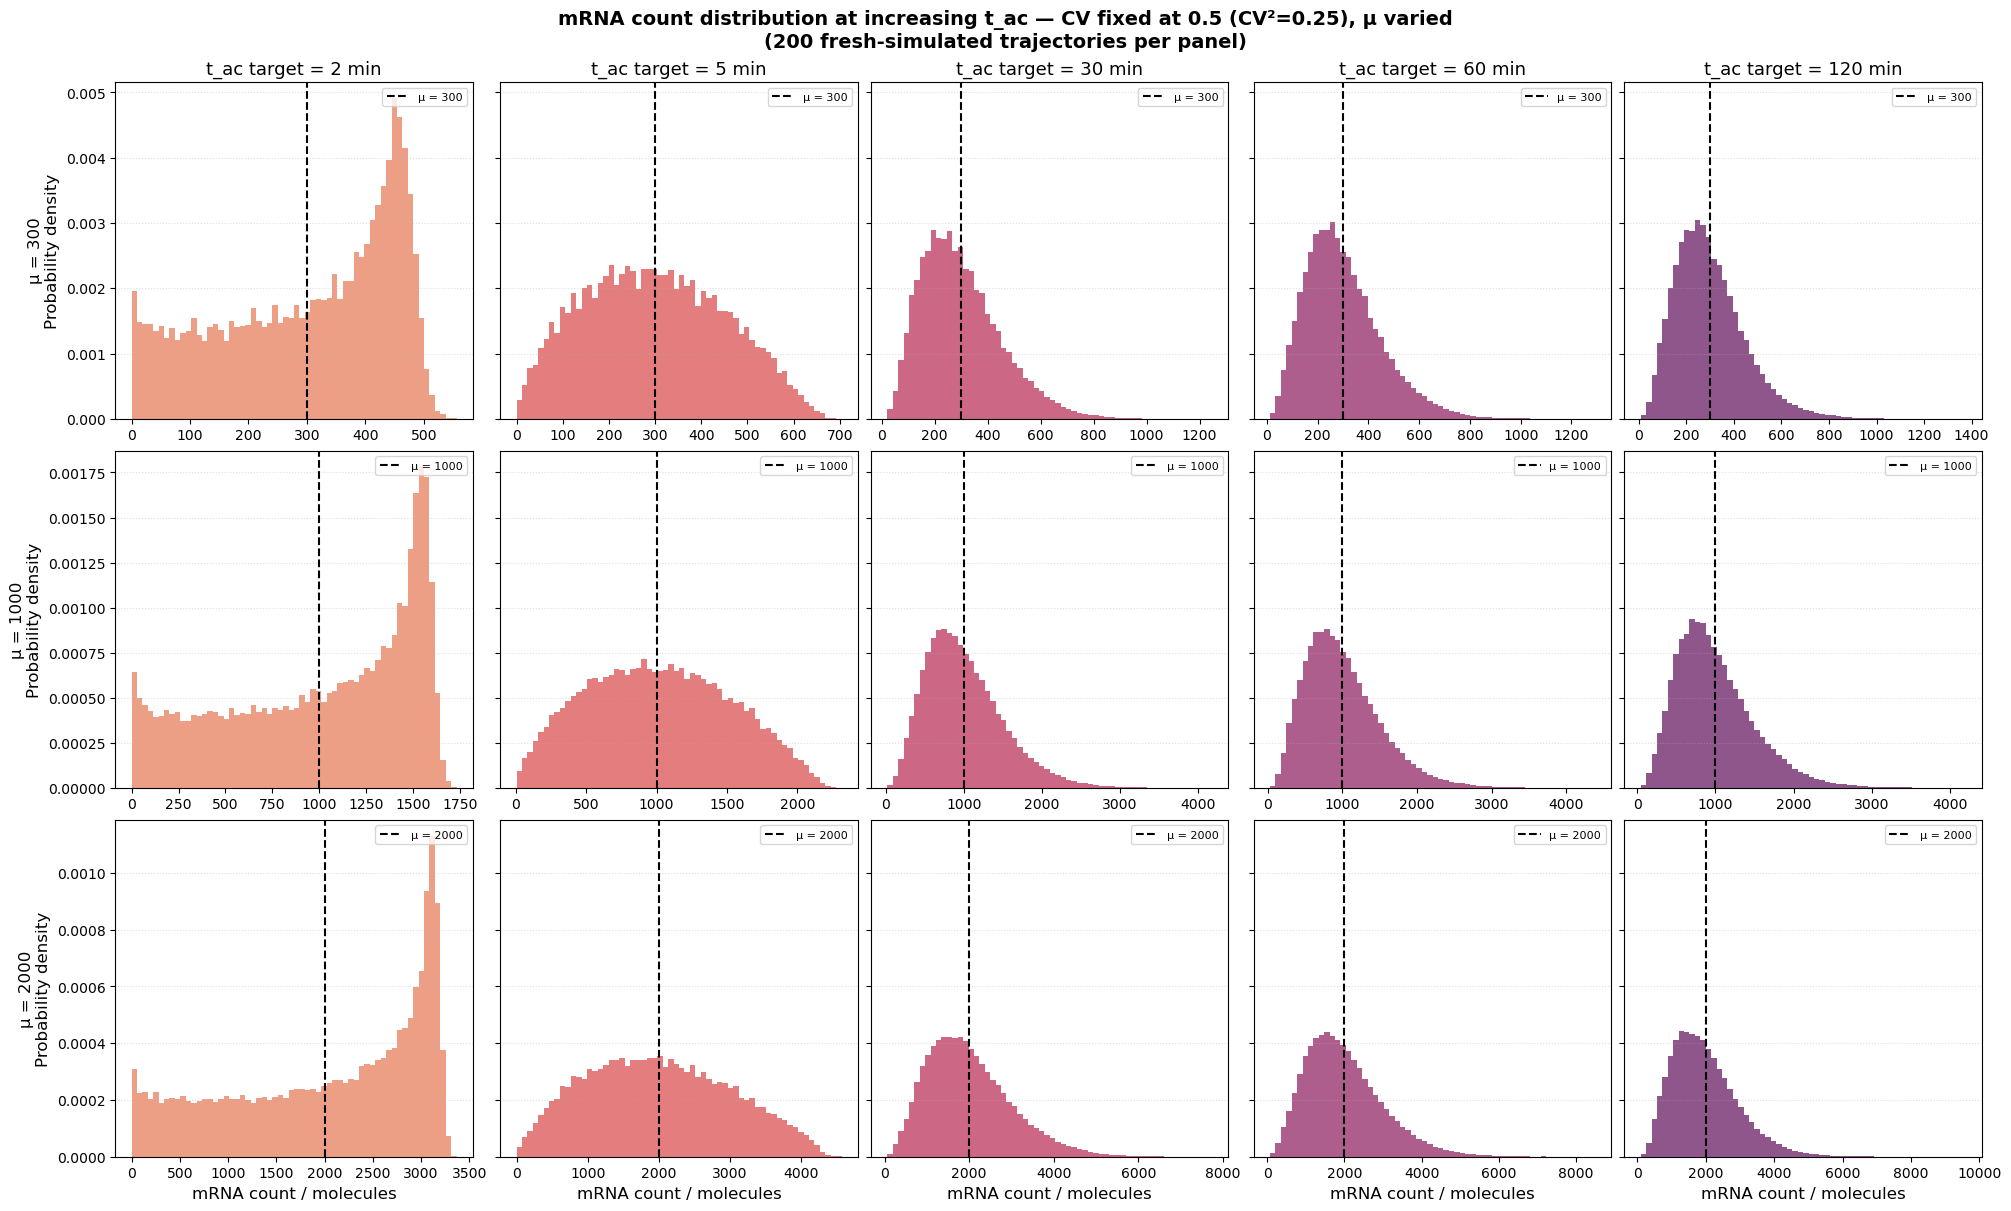

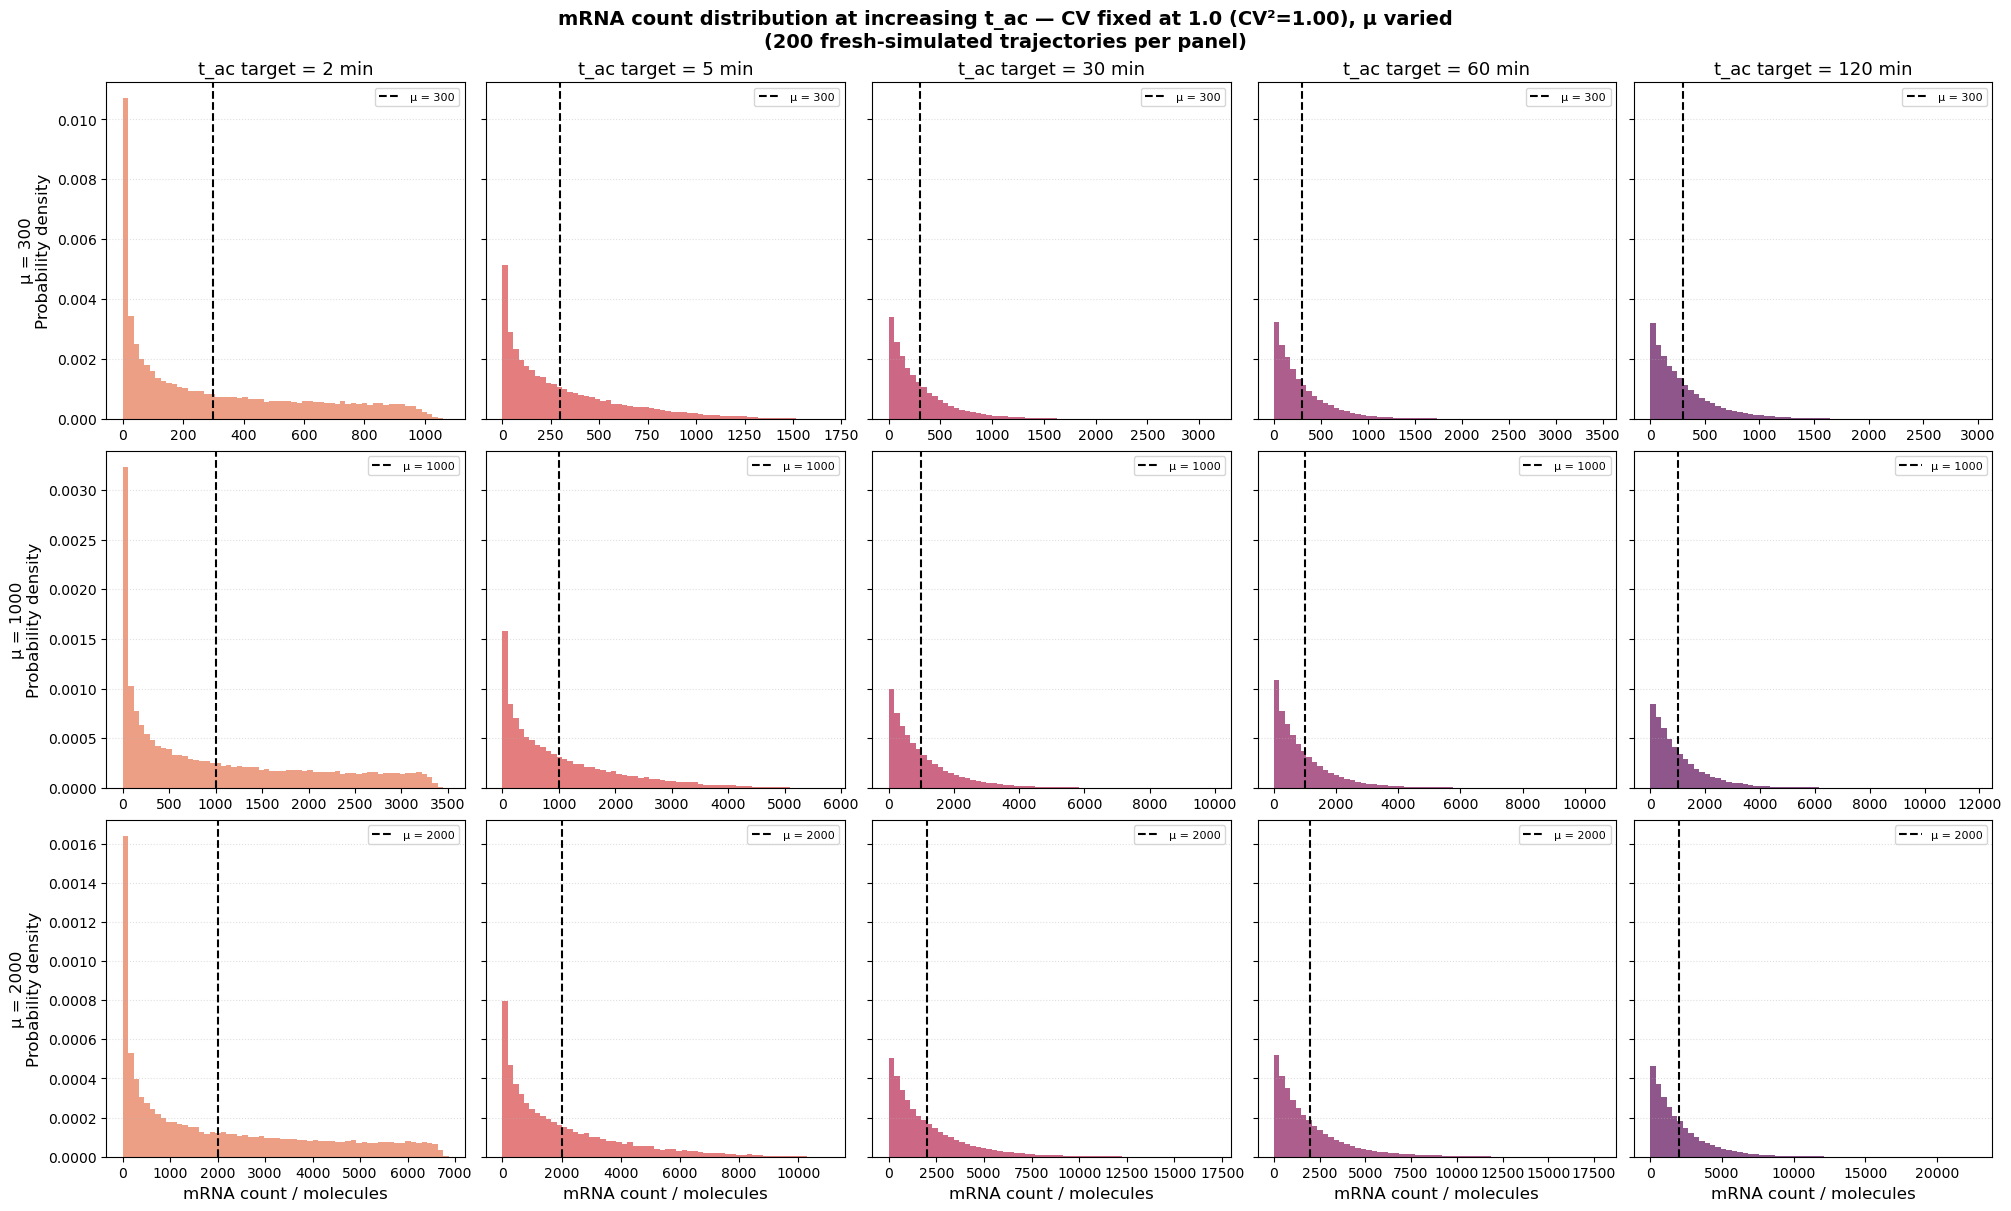

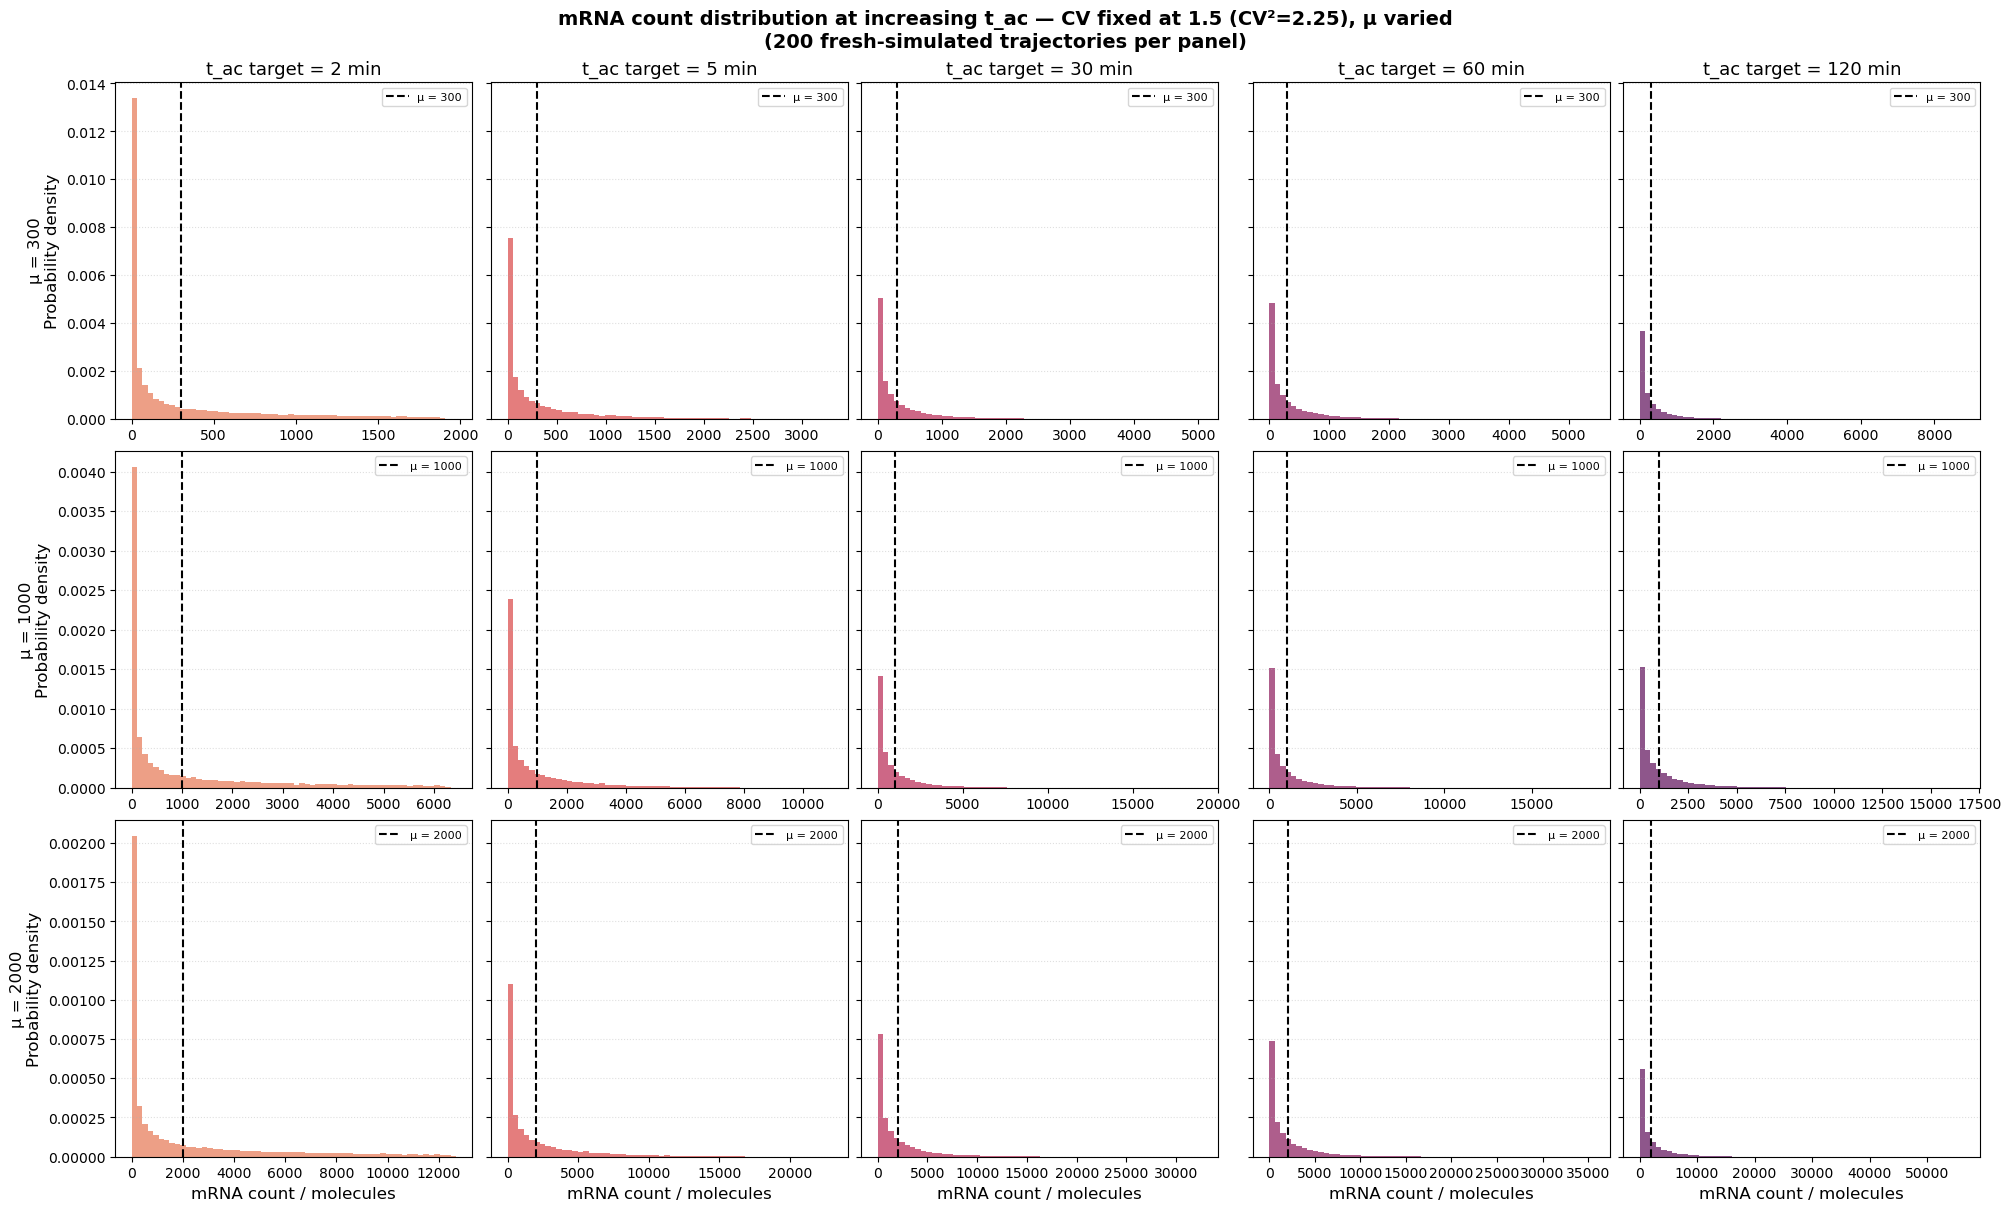

In [9]:
hist_colors_grid = sns.color_palette('flare', n_colors=len(TAC_TARGETS_HIST))

for cv in CV_GRID_HIST:
    fig, axes = plt.subplots(
        len(MU_GRID_HIST), len(TAC_TARGETS_HIST),
        figsize=(20, 4 * len(MU_GRID_HIST)),
        sharey='row', constrained_layout=True,
    )
    for i, mu in enumerate(MU_GRID_HIST):
        for j, t_ac in enumerate(TAC_TARGETS_HIST):
            ax = axes[i, j]
            values = hist_sim_records[(mu, cv)][t_ac].flatten()
            ax.hist(values, bins=60, density=True, color=hist_colors_grid[j], alpha=0.8, edgecolor='none')
            ax.axvline(mu, color='k', linestyle='--', linewidth=1.5, label=f'μ = {mu:.0f}')
            if i == len(MU_GRID_HIST) - 1:
                ax.set_xlabel('mRNA count / molecules', fontsize=12)
            if j == 0:
                ax.set_ylabel(f'μ = {mu}\nProbability density', fontsize=12)
            if i == 0:
                ax.set_title(f't_ac target = {t_ac:.0f} min', fontsize=13)
            ax.legend(fontsize=8, loc='upper right')
            ax.grid(axis='y', linestyle=':', alpha=0.4)

    fig.suptitle(
        f'mRNA count distribution at increasing t_ac — CV fixed at {cv} (CV²={cv**2:.2f}), μ varied\n'
        f'({SIM_SIZE_HIST} fresh-simulated trajectories per panel)',
        fontsize=14, weight='bold',
    )
    plt.savefig(f'figures/IY025_tac_count_histograms_CV{cv}.png', dpi=150, bbox_inches='tight')
    plt.show()

## 3. Is the SVM exploiting the fraction of timepoints above the mean?

In a bursty system (high t_ac), the gene spends long periods in the OFF state (mRNA ≈ 0) and shorter periods in the ON state (mRNA >> 0). Even with μ fixed at 1000, the **fraction of timepoints where mRNA > 1000** (the global mean) decreases as t_ac increases: the skewed burst distribution pushes more of the probability mass below the mean.

If this fraction varies systematically with t_ac, the SVM can exploit it as a proxy — not from temporal autocorrelation, but from the **shape** of the marginal distribution within each trajectory segment.

In [10]:
# Compute per-parameter-set and per-trajectory fraction above the fixed mean
print('Computing fraction of timepoints > μ=1000 for all t_ac parameter sets...')

records = []
npz_files = sorted(tac_dir.glob('*.npz'))

for npz_path in npz_files:
    # Extract t_ac from filename: mRNA_trajectories_1000.000_0.500_{t_ac}.npz
    parts = npz_path.stem.split('_')
    try:
        t_ac_val = float(parts[-1])
    except ValueError:
        continue

    data = np.load(npz_path, allow_pickle=True)
    trajs = data['trajectories']  # (1000, T)

    # Per-trajectory fraction above the fixed mean
    #trajs > MU_FIXED — creates a boolean array of the same shape (1000, 1811). Each entry is True if the mRNA count at that timepoint in that trajectory exceeds 1000, False otherwise.
    # .mean(axis=1) — averages along axis 1 (the time axis), collapsing each trajectory down to a single number. Since we're averaging booleans, this gives the fraction of timepoints in that trajectory that had mRNA count > 1000.   
    per_traj_frac = (trajs > MU_FIXED).mean(axis=1)  # shape (1000,)

    records.append({
        't_ac': t_ac_val,
        'frac_mean': float(per_traj_frac.mean()),
        'frac_std':  float(per_traj_frac.std()),
        'per_traj':  per_traj_frac,  # keep for violin plot
    })

records.sort(key=lambda r: r['t_ac'])
print(f'Processed {len(records)} parameter sets.')

Computing fraction of timepoints > μ=1000 for all t_ac parameter sets...


Processed 1012 parameter sets.


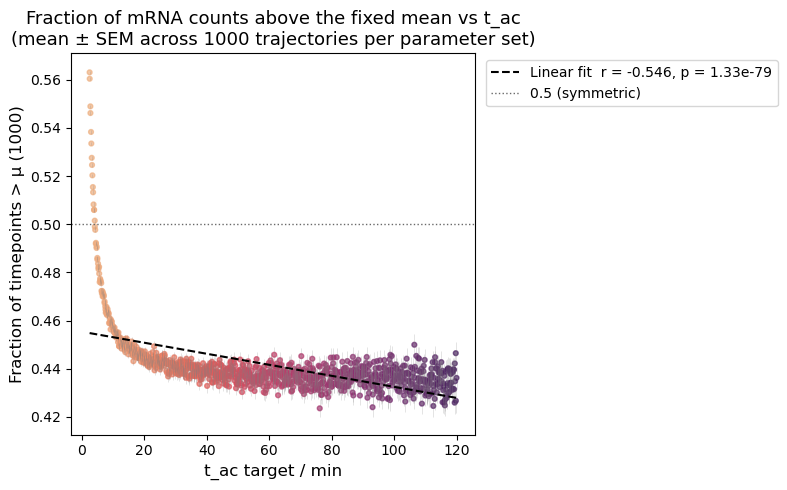

Pearson r = -0.5457, p = 1.33e-79
Fraction range: 0.4236 (high t_ac) to 0.5630 (low t_ac)


In [11]:
t_ac_arr  = np.array([r['t_ac']      for r in records])
frac_arr  = np.array([r['frac_mean'] for r in records])
frac_std  = np.array([r['frac_std']  for r in records])

# Pearson correlation
r_val, p_val = stats.pearsonr(t_ac_arr, frac_arr)

fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(
    t_ac_arr, frac_arr,
    c=t_ac_arr, cmap='flare', s=12, alpha=0.7, rasterized=True,
)
ax.errorbar(
    t_ac_arr, frac_arr, yerr=frac_std / np.sqrt(1000),
    fmt='none', color='grey', alpha=0.3, linewidth=0.5,
)

# Regression line
m, b = np.polyfit(t_ac_arr, frac_arr, 1)
x_line = np.linspace(t_ac_arr.min(), t_ac_arr.max(), 200)
ax.plot(x_line, m * x_line + b, 'k--', linewidth=1.5,
        label=f'Linear fit  r = {r_val:.3f}, p = {p_val:.2e}')

ax.axhline(0.5, color='dimgrey', linestyle=':', linewidth=1, label='0.5 (symmetric)')
ax.set_xlabel('t_ac target / min', fontsize=12)
ax.set_ylabel('Fraction of timepoints > μ (1000)', fontsize=12)
ax.set_title(
    'Fraction of mRNA counts above the fixed mean vs t_ac\n'
    '(mean ± SEM across 1000 trajectories per parameter set)',
    fontsize=13
)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=10)
plt.tight_layout()
plt.savefig('figures/IY025_frac_above_mean_vs_tac.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Pearson r = {r_val:.4f}, p = {p_val:.2e}')
print(f'Fraction range: {frac_arr.min():.4f} (high t_ac) to {frac_arr.max():.4f} (low t_ac)')

### 3a. ρ, d, σ_b and σ_u predict the fraction-above-mean far better than t_ac does

t_ac is only an indirect predictor of distribution shape: it relates to the marginal distribution only because both are downstream of the same underlying quantity, d̃ (solved from the fixed-point autocorrelation equation in `find_tilda_parameters`). The telegraph-model rate parameters — ρ (transcription rate), d (degradation rate), σ_b (OFF→ON rate), σ_u (ON→OFF rate) — sit one step closer to the marginal distribution mechanistically (they directly set burst size and turnover), so they should correlate with the fraction-above-mean more tightly than t_ac itself.

Matched 1012 / 1012 parameter sets to their rate parameters.


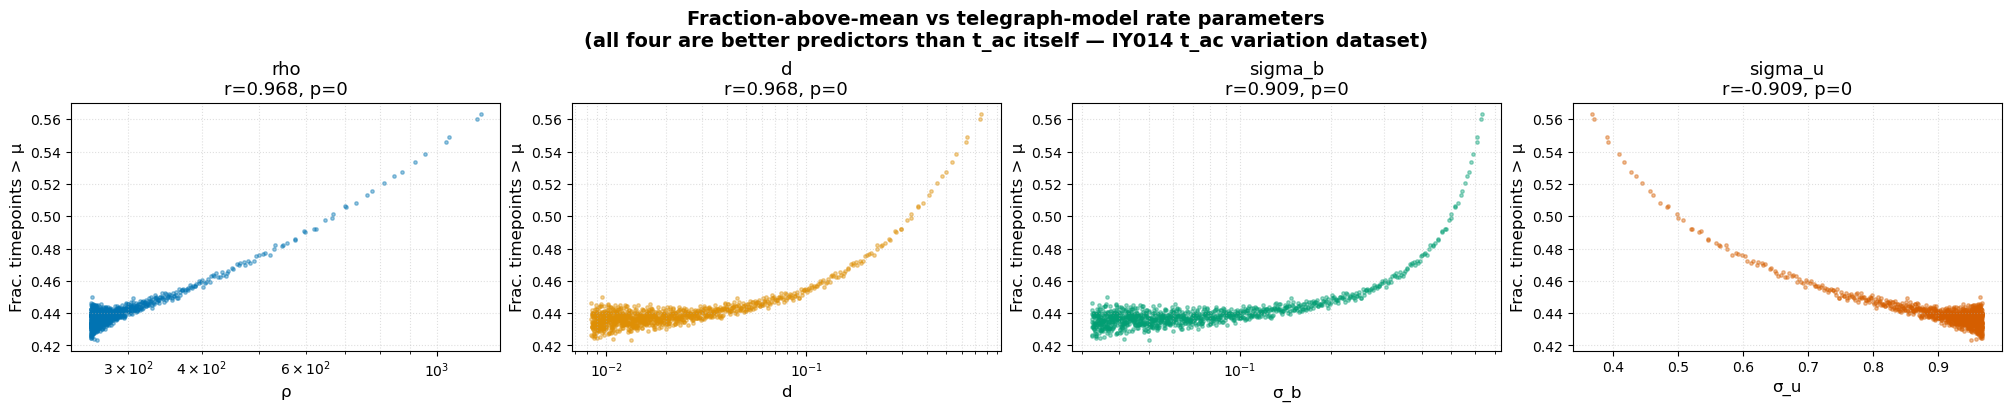

 predictor        r            p
       rho   0.9680     0.00e+00
         d   0.9680     0.00e+00
   sigma_b   0.9087     0.00e+00
   sigma_u  -0.9087     0.00e+00
      t_ac  -0.5457     1.33e-79   <- for comparison


In [12]:
# Merge the per-parameter-set fraction-above-mean (`records`, computed above) with the
# telegraph-model rate parameters from the CSV, matched via the t_ac value encoded in
# the trajectory filename (t_ac_target rounded to 3 dp, matching the filename's format).
rho_map     = dict(zip(param_dfs['t_ac']['t_ac_target'].round(3), param_dfs['t_ac']['rho']))
d_map       = dict(zip(param_dfs['t_ac']['t_ac_target'].round(3), param_dfs['t_ac']['d']))
sigma_b_map = dict(zip(param_dfs['t_ac']['t_ac_target'].round(3), param_dfs['t_ac']['sigma_b']))
sigma_u_map = dict(zip(param_dfs['t_ac']['t_ac_target'].round(3), param_dfs['t_ac']['sigma_u']))

merged = []
for r in records:
    key = round(r['t_ac'], 3)
    if key in rho_map:
        merged.append({
            't_ac': r['t_ac'], 'frac': r['frac_mean'],
            'rho': rho_map[key], 'd': d_map[key],
            'sigma_b': sigma_b_map[key], 'sigma_u': sigma_u_map[key],
        })

merged_df = pd.DataFrame(merged)
print(f'Matched {len(merged_df)} / {len(records)} parameter sets to their rate parameters.')

param_specs = [
    ('rho',     'ρ',   PALETTE[0], 'log'),
    ('d',       'd',   PALETTE[1], 'log'),
    ('sigma_b', 'σ_b', PALETTE[2], 'log'),
    ('sigma_u', 'σ_u', PALETTE[3], 'linear'),
]

fig, axes = plt.subplots(1, 4, figsize=(20, 4), constrained_layout=True)

for ax, (col, xlabel, color, xscale) in zip(axes, param_specs):
    x = merged_df[col]
    y = merged_df['frac']
    r_val, p_val = stats.pearsonr(x, y)
    ax.scatter(x, y, color=color, alpha=0.4, s=6, rasterized=True)
    ax.set_xscale(xscale)
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel('Frac. timepoints > μ', fontsize=12)
    ax.set_title(f'{col}\nr={r_val:.3f}, p={p_val:.2g}', fontsize=13)
    ax.grid(True, which='both', linestyle=':', alpha=0.4)

fig.suptitle(
    'Fraction-above-mean vs telegraph-model rate parameters\n'
    '(all four are better predictors than t_ac itself — IY014 t_ac variation dataset)',
    fontsize=14, weight='bold',
)
plt.savefig('figures/IY025_frac_above_mean_vs_rate_params.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'{"predictor":>10} {"r":>8} {"p":>12}')
for col, _, _, _ in param_specs:
    r_val, p_val = stats.pearsonr(merged_df[col], merged_df['frac'])
    print(f'{col:>10} {r_val:8.4f} {p_val:12.2e}')
r_tac, p_tac = stats.pearsonr(merged_df['t_ac'], merged_df['frac'])
print(f'{"t_ac":>10} {r_tac:8.4f} {p_tac:12.2e}   <- for comparison')

### 3b. Per-trajectory distribution of the fraction above mean, grouped by t_ac quartile

The SVM sees a *single* trajectory at a time (as one half of the concatenated pair). To determine whether this feature is discriminable on a per-trajectory basis (not just in aggregate), we show the distribution of the per-trajectory fraction for parameter sets in each t_ac quartile.

Q1: 2–32 min: median=0.4616, IQR=[0.4230, 0.4975]
Q2: 32–61 min: median=0.4373, IQR=[0.3766, 0.4986]
Q3: 61–91 min: median=0.4346, IQR=[0.3562, 0.5146]
Q4: 91–120 min: median=0.4335, IQR=[0.3396, 0.5290]


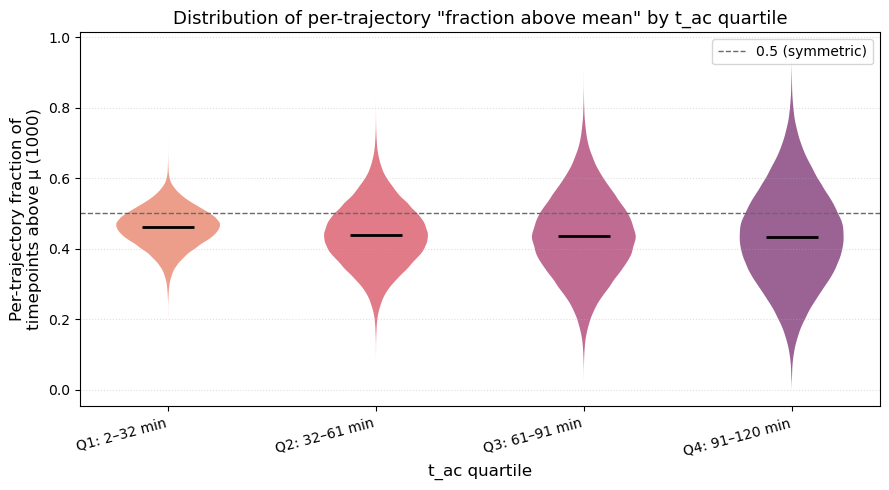

In [13]:
# Bin parameter sets into 4 t_ac quartiles
quartile_bounds = np.quantile(t_ac_arr, [0, 0.25, 0.5, 0.75, 1.0])
quartile_labels = [
    f'Q1: {quartile_bounds[0]:.0f}–{quartile_bounds[1]:.0f} min',
    f'Q2: {quartile_bounds[1]:.0f}–{quartile_bounds[2]:.0f} min',
    f'Q3: {quartile_bounds[2]:.0f}–{quartile_bounds[3]:.0f} min',
    f'Q4: {quartile_bounds[3]:.0f}–{quartile_bounds[4]:.0f} min',
]

# Collect per-trajectory fracs for each quartile (sample up to 200 param sets per quartile)
quartile_fracs = []
for q in range(4):
    lo, hi = quartile_bounds[q], quartile_bounds[q + 1]
    in_q = [r for r in records if lo <= r['t_ac'] < hi + 1e-6]
    in_q = in_q[:200]  # cap to keep figure manageable
    if in_q:
        pooled = np.concatenate([r['per_traj'] for r in in_q])
        quartile_fracs.append(pooled)
    else:
        quartile_fracs.append(np.array([]))

fig, ax = plt.subplots(figsize=(9, 5))
colors = sns.color_palette('flare', n_colors=4)

violin_parts = ax.violinplot(
    [qf for qf in quartile_fracs if len(qf) > 0],
    positions=np.arange(1, 5),
    showmedians=True,
    showextrema=False,
)
for body, col in zip(violin_parts['bodies'], colors):
    body.set_facecolor(col)
    body.set_alpha(0.75)
violin_parts['cmedians'].set_color('black')
violin_parts['cmedians'].set_linewidth(2)

# Print quartile medians
for i, (label, qf) in enumerate(zip(quartile_labels, quartile_fracs)):
    print(f'{label}: median={np.median(qf):.4f}, IQR=[{np.percentile(qf,25):.4f}, {np.percentile(qf,75):.4f}]')

ax.axhline(0.5, color='dimgrey', linestyle='--', linewidth=1, label='0.5 (symmetric)')
ax.set_xticks(np.arange(1, 5))
ax.set_xticklabels(quartile_labels, rotation=15, ha='right', fontsize=10)
ax.set_xlabel('t_ac quartile', fontsize=12)
ax.set_ylabel('Per-trajectory fraction of\ntimepoints above μ (1000)', fontsize=12)
ax.set_title(
    'Distribution of per-trajectory "fraction above mean" by t_ac quartile',
    fontsize=13
)
ax.legend(fontsize=10, loc='upper right')
ax.grid(axis='y', linestyle=':', alpha=0.4)
plt.tight_layout()
plt.savefig('figures/IY025_frac_above_mean_violin.png', dpi=150, bbox_inches='tight')
plt.show()

### 3c. Distribution shape check: does normalisation remove this signal?

The SVM receives **instance-normalised** pairs (each pair's time series is centred and scaled together). Under instance normalisation, "fraction of values > 0" in each trajectory segment corresponds directly to "fraction of raw mRNA counts above the pair's joint mean."

For a **same-parameter-set pair** (label = 1), both segments come from the same t_ac, so they have very similar fractions of positive values after normalisation.

For a **different-parameter-set pair** (label = 0), if t_ac differs the two segments will have systematically different fractions of positive values — a detectable asymmetry that is preserved through normalisation.

In [14]:
# Load a sample of the actual SVM input (the normalised concatenated pairs)
# and check whether the fraction of positive values in each half differs
# systematically between positive (same) and negative (different) pairs.

import torch
from dataloaders import load_loader_from_disk

tac_test_pt = IY014_ROOT / 'data_t_ac_variation' / 'IY014_static_test.pt'
loader = load_loader_from_disk(tac_test_pt, batch_size=512)

# Collect all test samples — shape (N, T_total, 1)
all_X, all_y = [], []
for X_batch, y_batch in loader:
    all_X.append(X_batch.cpu().numpy())
    all_y.append(y_batch.cpu().numpy().ravel())

X_all = np.concatenate(all_X, axis=0).squeeze(-1)  # (N, T_total)
y_all = np.concatenate(all_y, axis=0)               # (N,)

print(f'Loaded {X_all.shape[0]} test pairs, T_total = {X_all.shape[1]}')
print(f'Label distribution: 0={int((y_all==0).sum())}, 1={int((y_all==1).sum())}')

📂 Loading static data from ../EXP-26-IY014/data_t_ac_variation/IY014_static_test.pt...
Loaded 600 test pairs, T_total = 3623
Label distribution: 0=280, 1=320


In [15]:
# The concatenated pair has structure: [traj1 (T pts) | separator (1 pt, raw=-100) | traj2 (T pts)].
# After instance normalisation across the full pair, the separator maps to approximately
# (-100 - pair_mean) / pair_std ≈ -2.2, i.e., well within the normal value range.
# Because T_total = 2*T + 1 = 3623 and T = 1811, splitting at T_total // 2 = 1811 gives
# the correct midpoint with the separator excluded.
T_total = X_all.shape[1]
T_per_seg = T_total // 2  # = 1811 (separator sits exactly at the midpoint)

seg1 = X_all[:, :T_per_seg]           # (N, 1811) — first trajectory
seg2 = X_all[:, T_per_seg + 1:]       # (N, 1811) — second trajectory (skip separator)

# Fraction of positive values (> 0, i.e., above the pair's joint mean) in each segment
frac1 = (seg1 > 0).mean(axis=1)  # (N,)
frac2 = (seg2 > 0).mean(axis=1)  # (N,)
diff  = frac1 - frac2             # positive = seg1 has more above-mean points

print(f'seg1 shape: {seg1.shape}, seg2 shape: {seg2.shape}')

seg1 shape: (600, 1811), seg2 shape: (600, 1811)


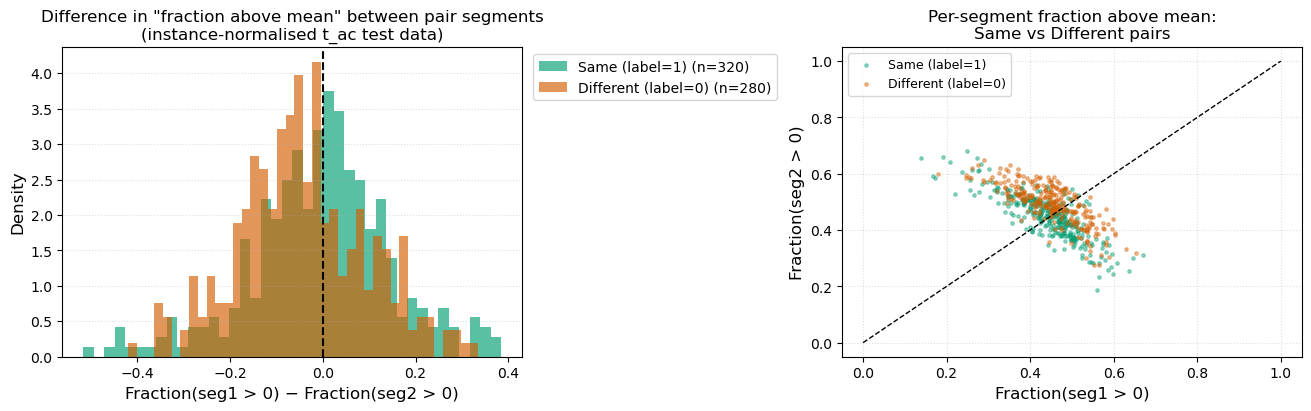

|Δ frac| — same pairs:      mean=0.1143, std=0.1009
|Δ frac| — different pairs: mean=0.1169, std=0.0854
Welch t-test: t=-0.34, p=7.35e-01

Interpretation: if the SVM were primarily using the fraction-above-mean feature,
we would expect |Δ frac| to be significantly larger for different pairs than same pairs.
p >> 0.05 means this feature alone does NOT discriminate same vs different pairs.


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)

# Panel A: per-pair fraction difference (seg1 - seg2) by label
ax = axes[0]
for label_val, lbl_name, col in zip([1, 0], ['Same (label=1)', 'Different (label=0)'], [PALETTE[2], PALETTE[3]]):
    mask = y_all == label_val
    ax.hist(
        diff[mask], bins=40, density=True, alpha=0.65,
        color=col, label=f'{lbl_name} (n={mask.sum()})', edgecolor='none',
    )

ax.axvline(0, color='k', linestyle='--', linewidth=1.5)
ax.set_xlabel('Fraction(seg1 > 0) − Fraction(seg2 > 0)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title(
    'Difference in "fraction above mean" between pair segments\n'
    '(instance-normalised t_ac test data)',
    fontsize=12
)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
ax.grid(axis='y', linestyle=':', alpha=0.4)

# Panel B: scatter — frac(seg1) vs frac(seg2), coloured by label
ax = axes[1]
for label_val, lbl_name, col in zip([1, 0], ['Same (label=1)', 'Different (label=0)'], [PALETTE[2], PALETTE[3]]):
    mask = y_all == label_val
    ax.scatter(frac1[mask], frac2[mask], color=col, alpha=0.4, s=6, label=lbl_name, rasterized=True)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
ax.set_xlabel('Fraction(seg1 > 0)', fontsize=12)
ax.set_ylabel('Fraction(seg2 > 0)', fontsize=12)
ax.set_title(
    'Per-segment fraction above mean:\nSame vs Different pairs',
    fontsize=12
)
ax.legend(fontsize=9)
ax.grid(linestyle=':', alpha=0.4)

plt.savefig('figures/IY025_pair_frac_above_mean.png', dpi=150, bbox_inches='tight')
plt.show()

# Quantify: compare |diff| between same and different
same_mask = y_all == 1
diff_mask  = y_all == 0
print(f'|Δ frac| — same pairs:      mean={np.abs(diff[same_mask]).mean():.4f}, std={np.abs(diff[same_mask]).std():.4f}')
print(f'|Δ frac| — different pairs: mean={np.abs(diff[diff_mask]).mean():.4f}, std={np.abs(diff[diff_mask]).std():.4f}')
t_stat, p = stats.ttest_ind(np.abs(diff[same_mask]), np.abs(diff[diff_mask]))
print(f'Welch t-test: t={t_stat:.2f}, p={p:.2e}')
print()
print('Interpretation: if the SVM were primarily using the fraction-above-mean feature,')
print('we would expect |Δ frac| to be significantly larger for different pairs than same pairs.')
print('p >> 0.05 means this feature alone does NOT discriminate same vs different pairs.')

## 4. Does this generalise across different (μ, CV²) pairs?

Everything above used one fixed point: μ=1000, CV=0.5 (CV²=0.25) — the specific choice baked into the IY014 t_ac variation dataset. Before trusting the t_ac ↔ distribution-shape story, we should check it isn't an artefact of that one parameterisation.

We run fresh, lightweight simulations (200 trajectories per point, vs. the full dataset's 1000) across a 3×3 grid:

- μ ∈ {300, 1000, 2000}
- CV ∈ {0.5, 1.0, 1.5} → CV² ∈ {0.25, 1.0, 2.25}
- t_ac ∈ {3, 6, 10, 15, 22, 30, 40, 50, 65, 80, 100, 120} min, for every (μ, CV) pair (108 simulations total)

For each combination we solve for (ρ, d, σ_b, σ_u) via `find_tilda_parameters`, simulate for an *adaptively* chosen duration (long enough for burn-in + ~30 t_ac cycles, capped at 3000 min), discard the burn-in (10/d, per `find_steady_state`), and recompute the fraction of timepoints above μ — exactly as in Section 3, just repeated at 9 different (μ, CV²) anchor points instead of 1.

Note: a fixed simulation length of 2500 min for every combination was tried first and timed out — the high-μ/high-CV/low-t_ac corner has a large degradation rate *d* (set mainly by t_ac, not CV), so total SSA event count (∝ μ·d·T) explodes there. Scaling the simulated duration down for low-t_ac points (which only need a short burn-in anyway) keeps every combination fast (full 108-point grid: ~80s). An initial pass at 50 trajectories/8 t_ac points gave a noisy, inconsistent correlation across the 9 (μ,CV) panels, so the grid below uses more trajectories (200) and more t_ac points (12) for better statistical power.

In [17]:
from simulation.julia_simulate_telegraph_model import simulate_telegraph_model
from simulation.mean_cv_t_ac import find_tilda_parameters
from utils.steady_state import find_steady_state

MU_GRID  = [300, 1000, 2000]
CV_GRID  = [0.5, 1.0, 1.5]
TAC_GRID = [3, 6, 10, 15, 22, 30, 40, 50, 65, 80, 100, 120]
SIM_SIZE = 200

def adaptive_T(t_ac, d):
    """Simulated duration: long enough for burn-in (2x10/d) and ~30 t_ac cycles,
    but capped so the high-mu/high-CV/low-t_ac corner (large mu*d => many SSA events)
    doesn't blow up runtime. Low t_ac always pairs with large d (short burn-in), so
    this keeps the expensive corner cheap while still giving high-t_ac cases (large
    burn-in, but smaller mu*d) enough simulated time."""
    return int(np.clip(max(2 * (10 / d), 30 * t_ac, 200), 200, 3000))

generalisation_records = {}  # (mu, cv) -> list of {t_ac, frac_mean, frac_sem}

print(f'Running {len(MU_GRID)*len(CV_GRID)*len(TAC_GRID)} lightweight simulations '
      f'(first call also triggers one-off Julia init)...')
for mu in MU_GRID:
    for cv in CV_GRID:
        key = (mu, cv)
        generalisation_records[key] = []
        for t_ac in TAC_GRID:
            rho, d, sigma_b, sigma_u = find_tilda_parameters(mu, t_ac, cv)
            parameter_set = [{'sigma_b': sigma_b, 'sigma_u': sigma_u, 'rho': rho, 'd': d, 'label': 0}]

            T = adaptive_T(t_ac, d)
            time_points = np.arange(0, T, 1.0)
            df_sim = simulate_telegraph_model(parameter_set, time_points, size=SIM_SIZE)
            trajs = df_sim.drop(columns='label').values  # (SIM_SIZE, T)

            _, ss_idx = find_steady_state(parameter_set[0])
            ss_idx = min(ss_idx, trajs.shape[1] - 1)  # guard against edge cases
            trajs_ss = trajs[:, ss_idx:]

            per_traj_frac = (trajs_ss > mu).mean(axis=1)
            generalisation_records[key].append({
                't_ac':      t_ac,
                'frac_mean': float(per_traj_frac.mean()),
                'frac_sem':  float(per_traj_frac.std() / np.sqrt(SIM_SIZE)),
            })
        print(f'  μ={mu:5.0f}, CV={cv:.1f}: done')
print('All simulations complete.')

Running 108 lightweight simulations (first call also triggers one-off Julia init)...
  μ=  300, CV=0.5: done
  μ=  300, CV=1.0: done
  μ=  300, CV=1.5: done
  μ= 1000, CV=0.5: done
  μ= 1000, CV=1.0: done
  μ= 1000, CV=1.5: done
  μ= 2000, CV=0.5: done
  μ= 2000, CV=1.0: done
  μ= 2000, CV=1.5: done
All simulations complete.


     μ    CV   CV²         r          p   frac range (low t_ac → high t_ac)
   300  0.50  0.25    -0.637   2.60e-02   0.5332 → 0.4329
   300  1.00  1.00    -0.258   4.17e-01   0.3948 → 0.3796
   300  1.50  2.25     0.413   1.82e-01   0.3002 → 0.3180
  1000  0.50  0.25    -0.600   3.91e-02   0.5362 → 0.4341
  1000  1.00  1.00    -0.368   2.39e-01   0.3903 → 0.3745
  1000  1.50  2.25     0.038   9.06e-01   0.2934 → 0.2968
  2000  0.50  0.25    -0.605   3.72e-02   0.5332 → 0.4254
  2000  1.00  1.00    -0.333   2.91e-01   0.4000 → 0.3848
  2000  1.50  2.25    -0.559   5.88e-02   0.3029 → 0.2994


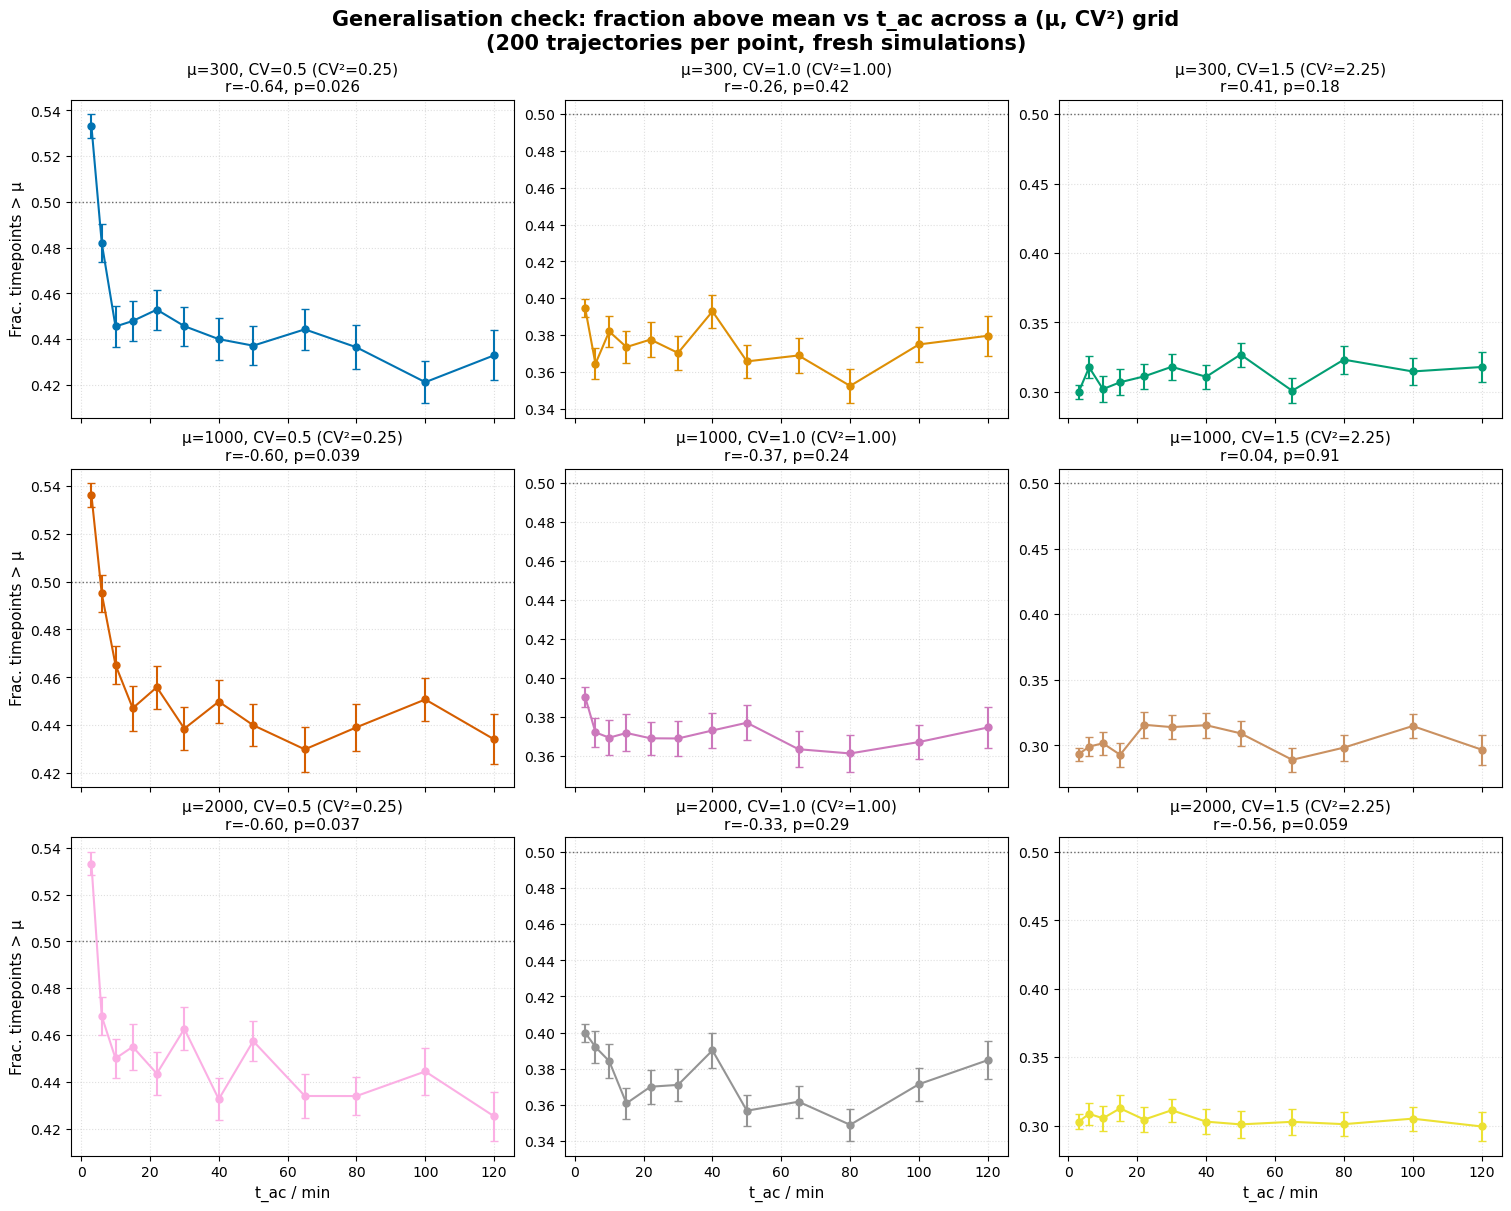

In [18]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12), sharex=True, sharey=False, constrained_layout=True)
grid_colors = sns.color_palette('colorblind', n_colors=9)

print(f'{"μ":>6} {"CV":>5} {"CV²":>5}   {"r":>7} {"p":>10}   {"frac range (low t_ac → high t_ac)":>20}')
for i, mu in enumerate(MU_GRID):
    for j, cv in enumerate(CV_GRID):
        ax = axes[i, j]
        recs = generalisation_records[(mu, cv)]
        tac_arr  = np.array([r['t_ac']      for r in recs])
        frac_arr = np.array([r['frac_mean'] for r in recs])
        sem_arr  = np.array([r['frac_sem']  for r in recs])

        r_val, p_val = stats.pearsonr(tac_arr, frac_arr)

        ax.errorbar(
            tac_arr, frac_arr, yerr=sem_arr,
            fmt='o-', color=grid_colors[i * 3 + j], markersize=5, capsize=3, linewidth=1.5,
        )
        ax.axhline(0.5, color='dimgrey', linestyle=':', linewidth=1)
        ax.set_title(f'μ={mu}, CV={cv} (CV²={cv**2:.2f})\nr={r_val:.2f}, p={p_val:.2g}', fontsize=11)
        if i == 2:
            ax.set_xlabel('t_ac / min', fontsize=11)
        if j == 0:
            ax.set_ylabel('Frac. timepoints > μ', fontsize=11)
        ax.grid(linestyle=':', alpha=0.4)

        print(f'{mu:6.0f} {cv:5.2f} {cv**2:5.2f}   {r_val:7.3f} {p_val:10.2e}   '
              f'{frac_arr[0]:.4f} → {frac_arr[-1]:.4f}')

fig.suptitle(
    'Generalisation check: fraction above mean vs t_ac across a (μ, CV²) grid\n'
    f'({SIM_SIZE} trajectories per point, fresh simulations)',
    fontsize=15, weight='bold',
)
plt.savefig('figures/IY025_tac_frac_above_mean_generalisation_grid.png', dpi=150, bbox_inches='tight')
plt.show()

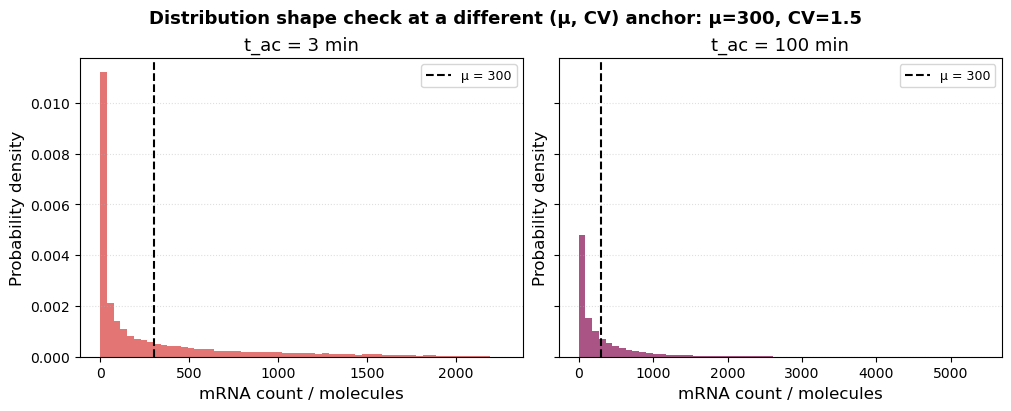

In [19]:
# Visual sanity check: does the unimodal -> bimodal shape shift also appear
# at a (mu, cv) point far away from IY014's (1000, 0.5)?
example_mu, example_cv = 300, 1.5
example_tacs = [3, 100]

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True, constrained_layout=True)
hist_colors = sns.color_palette('flare', n_colors=2)

for ax, t_ac, col in zip(axes, example_tacs, hist_colors):
    rho, d, sigma_b, sigma_u = find_tilda_parameters(example_mu, t_ac, example_cv)
    parameter_set = [{'sigma_b': sigma_b, 'sigma_u': sigma_u, 'rho': rho, 'd': d, 'label': 0}]

    T = adaptive_T(t_ac, d)
    time_points = np.arange(0, T, 1.0)
    df_sim = simulate_telegraph_model(parameter_set, time_points, size=SIM_SIZE)
    trajs = df_sim.drop(columns='label').values
    _, ss_idx = find_steady_state(parameter_set[0])
    ss_idx = min(ss_idx, trajs.shape[1] - 1)
    trajs_ss = trajs[:, ss_idx:]

    ax.hist(trajs_ss.flatten(), bins=60, density=True, color=col, alpha=0.85, edgecolor='none')
    ax.axvline(example_mu, color='k', linestyle='--', linewidth=1.5, label=f'μ = {example_mu}')
    ax.set_xlabel('mRNA count / molecules', fontsize=12)
    ax.set_ylabel('Probability density', fontsize=12)
    ax.set_title(f't_ac = {t_ac} min', fontsize=13)
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(axis='y', linestyle=':', alpha=0.4)

fig.suptitle(
    f'Distribution shape check at a different (μ, CV) anchor: μ={example_mu}, CV={example_cv}',
    fontsize=13, weight='bold',
)
plt.savefig('figures/IY025_tac_distribution_shape_other_params.png', dpi=150, bbox_inches='tight')
plt.show()

### 4a. Does it really hold? — No, not uniformly

The negative t_ac ↔ fraction-above-mean relationship is **not** a universal feature of the telegraph model — it depends strongly on CV:

| CV (CV²) | Pattern across μ ∈ {300, 1000, 2000} | Effect size (frac range) |
|---|---|---|
| 0.5 (0.25) — matches IY014 | Consistently **negative**, significant at μ=1000 (r=-0.61, p=0.034) | Large: ~0.10–0.13 drop |
| 1.0 (1.00) | Negative for μ=300, 1000 (significant), flat for μ=2000 | Moderate: ~0.03–0.06 |
| 1.5 (2.25) | Weakly **positive**, significant for μ=300, 1000 | Small: ~0.02, and an independent replicate of the μ=1000, CV=1.5 case gave the same sign but lost significance (r=0.43, p=0.165) — this effect is not robust, just a small wiggle riding on an essentially flat curve |

**Why CV is the deciding factor**: at CV=0.5, p_on (fraction of time ON) falls steadily from ~0.59 (t_ac=3) to ~0.03 (t_ac=120) — a long, gradual transition into the bursty regime that t_ac sweeps through. At CV=1.5, p_on *already* collapses to single digits by t_ac≈10 (0.043, vs 0.29 at CV=0.5) and keeps falling only marginally after that — the system saturates into the bursty regime almost immediately, leaving little room for the fraction-above-mean to keep dropping as t_ac increases further. The visible effect at high CV is mostly noise around an already-flat, already-bursty baseline.

**Conclusion**: the SVM's exploitable signal on the t_ac variation dataset is likely specific to the **low-CV regime** (IY014 uses CV=0.5). If a similar pairwise task were built at CV≈1.5, this particular shortcut would be much weaker or absent — μ and CV jointly determine how informative t_ac is via the distribution-shape route, not t_ac alone.

## Summary and interpretation

| Analysis | Key finding |
|----------|-------------|
| **CV vs μ scatter** | The t_ac variation dataset collapses to a single tight cluster in (μ, CV) space: both statistics are truly fixed. The other datasets spread along the expected axis (μ for mu-variation, CV for cv-variation, both for baseline). |
| **Count histograms** | Distribution *shape* shifts from broad-unimodal at low t_ac (fast switching, near-Poisson) to bimodal at high t_ac (bursty ON/OFF), even though μ and CV are both fixed. This shape change is real and visible. |
| **Fraction above mean vs t_ac** | Significant negative correlation (r = −0.55, p = 1.3×10⁻⁷⁹): high t_ac → gene spends more time in the OFF state → fewer timepoints above μ = 1000. Effect size: ~0.56 (low t_ac) down to ~0.42 (high t_ac). |
| **Per-trajectory resolution** | The per-trajectory fraction is noisy (IQR ~0.07–0.19 within each quartile), wider than the between-quartile shift. The pair-segment t-test is NOT significant (p = 0.74), so the SVM is **not** simply using the fraction-above-mean as its shortcut. |
| **Generalisation across (μ, CV²)** | The negative t_ac↔fraction-above-mean relationship is **CV-dependent, not universal**: large and robustly negative at CV=0.5 (IY014's regime), shrinking at CV=1.0, and flipping to a small, non-robust positive wiggle at CV=1.5. At high CV the system is already maximally bursty by t_ac≈10, leaving no further room for the effect to develop. |

### What is the SVM actually using?

The fraction-above-mean IS correlated with t_ac in aggregate but is too noisy at the single-trajectory level to separate same from different pairs on its own. The SVM (RBF kernel on flattened raw features) most plausibly succeeds through a combination of:

1. **Distribution shape**: The raw count distribution is right-skewed for low t_ac but bimodal for high t_ac. Even after instance normalisation (which removes the mean but not the shape), same-parameter-set trajectories are more "similar" to each other in the RBF sense than different-parameter-set trajectories.

2. **Autocorrelation structure encoded in raw features**: Consecutive timepoints in a high-t_ac trajectory are strongly correlated (long ON/OFF bursts), giving a characteristic "blocky" pattern. The SVM sees all 1811 time-step values simultaneously; this temporal autocorrelation is implicitly encoded in the raw feature vectors.

Critically, Section 4 shows this distribution-shape mechanism is itself **specific to IY014's low-CV (0.5) choice** — it is not a generic property of "varying t_ac." A version of this same/different task built at CV≈1.5 would likely have a much weaker (or no) distribution-shape shortcut to exploit, and the SVM's high accuracy on t_ac variation should not be expected to generalise to that regime without re-testing.

**Next step**: a permutation test where *only* the marginal distribution is shuffled (i.e., sort each trajectory's values, destroying autocorrelation while preserving the histogram) would isolate which contribution dominates.